协方差矩阵形状: (10, 10)
协方差矩阵对角线（各科目方差）: [ 87.81739713  90.85661006 104.62923323  63.7100712   66.2728099
  55.53097858 139.02612717 153.91822188 148.85978813 142.25910983]
特征值（前5个）: [269.99222318 160.58812126 153.71925698 141.8138494  127.95884782]
方差解释比例:
  PC1: 0.256 (25.6%)
  PC2: 0.153 (15.3%)
  PC3: 0.146 (14.6%)
  PC4: 0.135 (13.5%)
  PC5: 0.122 (12.2%)
降维后数据形状: (500, 3)


/home/dhu/miniconda3/envs/torch312/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 38376 (\N{CJK UNIFIED IDEOGRAPH-95E8}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/dhu/miniconda3/envs/torch312/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21151 (\N{CJK UNIFIED IDEOGRAPH-529F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/dhu/miniconda3/envs/torch312/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 35838 (\N{CJK UNIFIED IDEOGRAPH-8BFE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/dhu/miniconda3/envs/torch312/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 32500 (\N{CJK UNIFIED IDEOGRAPH-7EF4}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


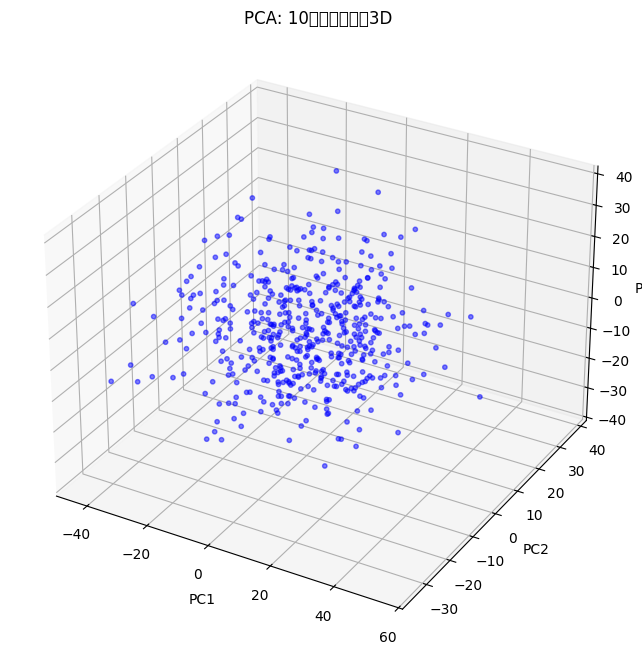

前3个主成分的特征向量（权重）:
PC1:
  Math: -0.554
  Physics: -0.564
  Chemistry: -0.597

PC2:
  Politics: 0.362
  Geography: 0.748
  Biology: -0.191
  PE: -0.507

PC3:
  Politics: 0.506
  Geography: -0.264
  Biology: 0.749
  PE: -0.324



In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 1. 构造500个样本的10维相关数据
np.random.seed(42)
n_students = 500
n_subjects = 10

# 假设前3门是数学相关，后3门是文科相关，其余独立
math_related = np.random.normal(75, 10, (n_students, 3))  # shape: (500, 3)
literature_related = np.random.normal(70, 8, (n_students, 3))  # shape: (500, 3)
independent = np.random.normal(80, 12, (n_students, 4))  # shape: (500, 4)

# 添加相关性：物理≈数学+噪声，化学≈数学+物理+噪声
math_related[:, 1] = math_related[:, 0] + np.random.normal(0, 3, n_students)  # 物理
math_related[:, 2] = 0.5 * math_related[:, 0] + 0.5 * math_related[:, 1] + np.random.normal(0, 4, n_students)  # 化学

# 组合成10维数据
X = np.column_stack([math_related, literature_related, independent])  # shape: (500, 10)

# 2. 中心化
X_centered = X - X.mean(axis=0)  # shape: (500, 10)

# 3. 计算协方差矩阵
Sigma = (X_centered.T @ X_centered) / len(X_centered)  # shape: (10, 10)
print("协方差矩阵形状:", Sigma.shape)
print("协方差矩阵对角线（各科目方差）:", np.diag(Sigma))

# 4. 特征分解 → 找主轴方向与长度
eigenvalues, eigenvectors = np.linalg.eigh(Sigma)  # eigenvalues: (10,), eigenvectors: (10, 10)
# eigh 按从小到大排序，我们反转一下
eigenvalues = eigenvalues[::-1]  # shape: (10,)
eigenvectors = eigenvectors[:, ::-1]  # shape: (10, 10)

print("特征值（前5个）:", eigenvalues[:5])
print("方差解释比例:")
explained_variance_ratio = eigenvalues / eigenvalues.sum()  # shape: (10,)
for i, ratio in enumerate(explained_variance_ratio[:5]):
    print(f"  PC{i+1}: {ratio:.3f} ({ratio*100:.1f}%)")

# 5. PCA：保留前3个主成分
V = eigenvectors[:, :3]  # 前3个特征向量, shape: (10, 3)
X_pca = X_centered @ V  # 500x10 投影到 500x3, shape: (500, 3)

print("降维后数据形状:", X_pca.shape)

# 6. 可视化前3个主成分（3D散点图）
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], alpha=0.5, c='blue', s=10)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('PCA: 10门功课降维到3D')
plt.show()

# 7. 分析主成分含义（查看特征向量）
print("前3个主成分的特征向量（权重）:")
subject_names = ['Math', 'Physics', 'Chemistry', 'Chinese', 'English', 'History', 'Politics', 'Geography', 'Biology', 'PE']
for i in range(3):
    print(f"PC{i+1}:")
    for j, name in enumerate(subject_names):
        weight = eigenvectors[j, i]
        if abs(weight) > 0.1:  # 只显示重要权重
            print(f"  {name}: {weight:.3f}")
    print()